[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/Quantlets/Ch_11/SFM_ch11_seminar/SFM_ch11_seminar.ipynb)

# Statistics of Financial Markets — Seminar 11: Fractal markets hypothesis and long memory

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- This seminar comes before Lecture 11: the slides "What You Need for Today" give every definition used here.
- Part A: computations on paper, checked in code. Part B: real data with inference and an interpretation question. Part C: an open question and an AI answer to audit.
- **[Solved]**: complete code and output, a model to follow. **[Proposed]**: write your own code in the empty cell.

> Quantlet `SFM_ch11_seminar`: student version of the Seminar 11 notebook. Solved exercises (A1, A3, A5, B1, B3, B5) are shown with code and output; the proposed exercises (A2, A4, A6, B2, B4, B6, C1, C2) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_11'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Seminar functions

- Returns; R/S, DFA, GPH and Lo's test; the ACF; Monte Carlo bands under i.i.d. Normal series; rolling exponents; simulation of fractional Gaussian noise and ARFIMA.
- Helpers for Part A: R/S step by step, $H$ from points of an R/S plot, fGn and ARFIMA numbers.

In [ ]:
from scipy import special
NAME = {'sp500': 'S&P 500', 'dax': 'DAX', 'bet': 'BET', 'btc': 'Bitcoin', 'tlv': 'Banca Transilvania', 'snp': 'OMV Petrom'}
START = {'sp500': '2000-01-01', 'dax': '2000-01-01', 'bet': '2000-01-01', 'btc': None, 'tlv': '2010-01-01', 'snp': '2010-01-01'}
ASSETS = ['sp500', 'dax', 'bet', 'btc', 'tlv', 'snp']
BAD_DAYS = {'tlv': ['2016-05-30', '2016-05-31']}
COLORS = {'sp500': '#1A3A6E', 'dax': '#17A2B8', 'bet': '#CD0000', 'btc': '#B5853F', 'tlv': '#E67E22', 'snp': '#2E7D32'}
SEED = 2026
NMIN = 10
WINDOW = 1000
STEP = 21
MC_REPS = 500
LO_CRIT = (0.809, 1.862)
GPH_POWER = 0.5
RS_EXAMPLE = [0.5, -0.3, 0.8, -0.2, 0.6, -0.1, 0.4, -0.7]
NILE_BREAK = 1898
H_LIST = [1, 2, 5, 10, 20, 50, 100, 250]
MC_N = [250, 500, 1000, 2500, 5000]
PHIS = [0.0, 0.1, 0.2, 0.3, 0.5]
HS_POWER = [0.5, 0.6, 0.7, 0.8]
DELTAS = [0.0, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]
PERS = [0.8, 0.9, 0.95, 0.98, 0.99]
SEM_REPS = 300
A1_X = [0.5, -0.3, 0.8, -0.2, 0.6, -0.1, 0.4, -0.7]
A2_X = [0.6, 0.4, 0.5, 0.3, -0.4, -0.6, -0.2, -0.5]
POINTS = [16, 64, 256]
CRISES = {'calm 2017': ('2017-01-01', '2017-12-31'), 'GFC 2008-09': ('2008-09-01', '2009-08-31'), 'COVID 2020-21': ('2020-02-15', '2021-02-14')}


def returns(k, start=None, end=None):
    """Daily log returns in % on the series' own calendar; known data errors removed."""
    r = log_returns(k, start or START.get(k)) if end is None else log_returns(k, start or START.get(k), end)
    if k in BAD_DAYS:
        r = r.drop(pd.to_datetime(BAD_DAYS[k]), errors='ignore')
    return r


def block_sizes(N, nmin=NMIN, nmax=None, num=20):
    """Block sizes for R/S and DFA: about `num` values spaced evenly on a log scale between nmin and N/4."""
    nmax = nmax or N // 4
    return np.unique(np.floor(np.logspace(np.log10(nmin), np.log10(nmax), num)).astype(int))


def rs_block(x):
    """R/S of one block: range of the cumulative deviations from the mean, divided by the standard deviation."""
    x = np.asarray(x, float)
    y = np.cumsum(x - x.mean())
    return (y.max() - y.min()) / x.std()


def rs_curve(x, sizes=None):
    """Average R/S over the non-overlapping blocks of each size n (Hurst 1951; Mandelbrot and Wallis 1969)."""
    x = np.asarray(x, float)
    sizes = block_sizes(len(x)) if sizes is None else np.asarray(sizes)
    out = []
    for n in sizes:
        m = len(x) // n
        X = x[:m * n].reshape(m, n)
        Y = np.cumsum(X - X.mean(axis=1, keepdims=True), axis=1)
        R = Y.max(axis=1) - Y.min(axis=1)
        S = X.std(axis=1)
        ok = S > 0
        out.append(np.mean(R[ok] / S[ok]))
    return sizes, np.array(out)


def hurst_rs(x, sizes=None):
    """Hurst exponent: slope of log(R/S)_n on log n."""
    n, rs = rs_curve(x, sizes)
    return float(np.polyfit(np.log10(n), np.log10(rs), 1)[0])


def dfa_curve(x, sizes=None):
    """DFA-1 (Peng et al. 1994): profile Y = cumsum(x - mean); in each block of size n a straight line is fitted
    to Y; F(n) is the root mean square of the deviations from the lines."""
    x = np.asarray(x, float)
    sizes = block_sizes(len(x)) if sizes is None else np.asarray(sizes)
    Y = np.cumsum(x - x.mean())
    F = []
    for n in sizes:
        m = len(Y) // n
        B = Y[:m * n].reshape(m, n)
        t = np.arange(n) - (n - 1) / 2
        b = (B - B.mean(axis=1, keepdims=True)) @ t / (t @ t)
        resid = B - B.mean(axis=1, keepdims=True) - np.outer(b, t)
        F.append(np.sqrt(np.mean(resid ** 2)))
    return sizes, np.array(F)


def hurst_dfa(x, sizes=None):
    """DFA exponent: slope of log F(n) on log n (equal to H for fractional Gaussian noise)."""
    n, F = dfa_curve(x, sizes)
    return float(np.polyfit(np.log10(n), np.log10(F), 1)[0])


def periodogram(x):
    """I(lambda_j) = |sum_t x_t exp(-i lambda_j t)|^2 / (2 pi T) at the Fourier frequencies lambda_j = 2 pi j / T."""
    x = np.asarray(x, float)
    T = len(x)
    I = np.abs(np.fft.fft(x - x.mean())) ** 2 / (2 * np.pi * T)
    j = np.arange(1, T // 2 + 1)
    return 2 * np.pi * j / T, I[1:T // 2 + 1]


def gph(x, power=GPH_POWER):
    """GPH estimator of d (Geweke and Porter-Hudak 1983; FHH 14.5.2): OLS slope of log I(lambda_j) on
    -log(4 sin^2(lambda_j / 2)), j = 1, ..., m = [T^power]; asymptotic standard error pi / sqrt(24 m)."""
    lam, I = periodogram(x)
    m = int(np.floor(len(x) ** power))
    X = -np.log(4 * np.sin(lam[:m] / 2) ** 2)
    y = np.log(I[:m])
    d = float(np.polyfit(X, y, 1)[0])
    return {'d': d, 'se': float(np.pi / np.sqrt(24 * m)), 'm': m, 'H': d + 0.5}


def lo_test(x, q=None):
    """Lo's (1991) modified R/S: V(q) = R / (sqrt(N) sigma(q)), sigma^2(q) the Newey-West variance with Bartlett
    weights 1 - j/(q+1); q = 0 gives the classical statistic. Default q: Andrews (1991) rule used by Lo,
    q = [(3N/2)^(1/3) (2 rho / (1 - rho^2))^(2/3)], rho the first-order autocorrelation.
    Short memory is rejected at 5% if V is outside [0.809, 1.862]."""
    x = np.asarray(x, float)
    N = len(x)
    xc = x - x.mean()
    Y = np.cumsum(xc)
    R = Y.max() - Y.min()
    g0 = xc @ xc / N
    rho = (xc[1:] @ xc[:-1] / N) / g0
    if q is None:
        q = int(np.floor((1.5 * N) ** (1 / 3) * (2 * abs(rho) / (1 - rho ** 2)) ** (2 / 3)))
    s2 = g0 + 2 * sum((1 - j / (q + 1)) * (xc[j:] @ xc[:-j] / N) for j in range(1, q + 1))
    V = R / np.sqrt(N * s2)
    V0 = R / np.sqrt(N * g0)
    return {'V': float(V), 'V0': float(V0), 'q': int(q), 'rho1': float(rho),
            'reject': bool(not LO_CRIT[0] <= V <= LO_CRIT[1]), 'reject0': bool(not LO_CRIT[0] <= V0 <= LO_CRIT[1])}


def acf(x, nlags):
    """Sample autocorrelations at lags 1..nlags."""
    x = np.asarray(x, float) - np.mean(x)
    g0 = x @ x
    return np.array([x[k:] @ x[:-k] / g0 for k in range(1, nlags + 1)])


def all_estimates(x):
    """R/S, DFA, GPH (d and H = d + 1/2) and Lo's test of one series."""
    g = gph(x)
    lo = lo_test(x)
    return {'n': int(len(x)), 'rs': hurst_rs(x), 'dfa': hurst_dfa(x), 'gph_d': g['d'], 'gph_se': g['se'],
            'gph_m': g['m'], 'gph_H': g['H'], 'lo_V': lo['V'], 'lo_V0': lo['V0'], 'lo_q': lo['q'],
            'lo_reject': lo['reject'], 'lo_reject0': lo['reject0']}


def fgn_acvf(n, H):
    """Autocovariances of standard fractional Gaussian noise: 0.5 (|k+1|^2H - 2|k|^2H + |k-1|^2H), k = 0..n-1."""
    k = np.arange(n, dtype=float)
    return 0.5 * (np.abs(k + 1) ** (2 * H) - 2 * k ** (2 * H) + np.abs(k - 1) ** (2 * H))


def arfima_acf(n, d):
    """Autocorrelations of ARFIMA(0,d,0): rho_k = Gamma(1-d) Gamma(k+d) / (Gamma(d) Gamma(k+1-d)), k = 0..n-1,
    computed with the recursion rho_k = rho_{k-1} (k - 1 + d) / (k - d)."""
    r = np.ones(n)
    for k in range(1, n):
        r[k] = r[k - 1] * (k - 1 + d) / (k - d)
    return r


def arfima_var(d):
    """Variance of ARFIMA(0,d,0) with unit innovation variance: Gamma(1 - 2d) / Gamma(1 - d)^2."""
    return float(np.exp(special.gammaln(1 - 2 * d) - 2 * special.gammaln(1 - d)))


def circulant_gaussian(acvf, rng, size=1):
    """Exact simulation of a stationary Gaussian series with autocovariances acvf[0..n-1] by circulant embedding
    (Davies and Harte); returns an array (size, n)."""
    n = len(acvf)
    c = np.concatenate([acvf, acvf[-2:0:-1]])
    M = len(c)
    lam = np.clip(np.fft.fft(c).real, 0, None)
    Z = rng.standard_normal((size, M)) + 1j * rng.standard_normal((size, M))
    W = np.fft.fft(np.sqrt(lam / M) * Z, axis=1)
    return W.real[:, :n]


def sim_fgn(n, H, rng, size=1):
    return circulant_gaussian(fgn_acvf(n, H), rng, size)


def sim_arfima(n, d, rng, size=1):
    return circulant_gaussian(arfima_var(d) * arfima_acf(n, d), rng, size)


def sim_garch(n, omega, alpha, beta, rng, size=1, burn=500):
    """GARCH(1,1) with Normal innovations, `size` independent paths of length n (unconditional variance 1 if
    omega = 1 - alpha - beta)."""
    z = rng.standard_normal((size, n + burn))
    s2 = np.full(size, omega / (1 - alpha - beta))
    e = np.empty((size, n + burn))
    for t in range(n + burn):
        e[:, t] = np.sqrt(s2) * z[:, t]
        s2 = omega + alpha * e[:, t] ** 2 + beta * s2
    return e[:, burn:]


def mc_null(N, reps=MC_REPS, seed=SEED):
    """Distribution of the R/S, DFA and GPH estimates for i.i.d. Normal series of length N."""
    rng = np.random.default_rng(seed + N)
    rs, dfa, gp = [], [], []
    sizes = block_sizes(N)
    for _ in range(reps):
        x = rng.standard_normal(N)
        rs.append(hurst_rs(x, sizes))
        dfa.append(hurst_dfa(x, sizes))
        gp.append(gph(x)['H'])
    out = {}
    for k, v in [('rs', rs), ('dfa', dfa), ('gph', gp)]:
        v = np.array(v)
        out[k] = {'mean': float(v.mean()), 'sd': float(v.std()), 'q025': float(np.quantile(v, 0.025)),
                  'q975': float(np.quantile(v, 0.975))}
    return out


def rolling_hurst(x, window=WINDOW, step=STEP, est=hurst_dfa):
    """Hurst exponent on rolling windows; the value is dated at the last day of the window."""
    x = pd.Series(x)
    sizes = block_sizes(window)
    idx, val = [], []
    for e in range(window, len(x) + 1, step):
        idx.append(x.index[e - 1])
        val.append(est(x.values[e - window:e], sizes))
    return pd.Series(val, index=idx)


def rs_steps(x):
    """All steps of the R/S statistic of one short block: mean, deviations, cumulative deviations, R, S, R/S."""
    x = np.asarray(x, float)
    dev = x - x.mean()
    Y = np.cumsum(dev)
    R = Y.max() - Y.min()
    S = x.std()
    return {'x': x.tolist(), 'mean': float(x.mean()), 'dev': dev.tolist(), 'Y': Y.tolist(), 'max': float(Y.max()),
            'min': float(Y.min()), 'kmax': int(np.argmax(Y)) + 1, 'kmin': int(np.argmin(Y)) + 1, 'R': float(R),
            'S': float(S), 'RS': float(R / S), 'sumsq': float(dev @ dev)}


def rs_by_hand(x):
    """R/S of one short block, every step."""
    return rs_steps(x)


def hurst_from_points(ns, rs):
    """H = OLS slope of log10(R/S)_n on log10 n (three points: the slope between the outer points if the
    block sizes are equally spaced on the log scale)."""
    ln, lr = np.log10(ns), np.log10(rs)
    b, a = np.polyfit(ln, lr, 1)
    return {'n': list(map(int, ns)), 'rs': [float(v) for v in rs], 'log_n': ln.tolist(), 'log_rs': lr.tolist(),
            'H': float(b), 'intercept': float(a)}


def rs_points(k, sizes=POINTS):
    """Average R/S of the daily returns of a series at three block sizes (rounded to 2 decimals for paper work)."""
    n, v = rs_curve(returns(k).values, sizes)
    return [round(float(x), 2) for x in v]


def fgn_numbers(H, sigma=1.2, h=10, z=2.326):
    """Fractional Gaussian noise: rho(1), rho(10) exact and asymptotic, the h-day scaling factor h^H against sqrt(h),
    one-day and h-day VaR 1% (Normal, daily sigma in %), the fractal dimension D = 2 - H of the price path."""
    a = fgn_acvf(11, H)
    return {'H': H, 'rho1': float(a[1]), 'rho10': float(a[10]), 'rho10_asy': float(H * (2 * H - 1) * 10 ** (2 * H - 2)),
            'scale': float(h ** H), 'sqrt': float(np.sqrt(h)), 'var1': float(z * sigma), 'varh': float(z * sigma * h ** H),
            'varh_sqrt': float(z * sigma * np.sqrt(h)), 'diff_pct': float(100 * (h ** H / np.sqrt(h) - 1)), 'D': 2 - H}


def arfima_numbers(d, lags=(10, 50), level=0.05):
    """ARFIMA(0,d,0): MA weights psi_j, fractional-difference weights pi_j, autocorrelations; an AR(1) with the same
    rho(1) for comparison; the first lag at which each autocorrelation falls below `level`."""
    rho = arfima_acf(2001, d)
    psi = [1.0, d, d * (1 + d) / 2]
    pi = [1.0, -d, -d * (1 - d) / 2]
    phi = rho[1]
    def first(r):
        below = np.abs(r[1:]) < level
        return int(np.argmax(below) + 1) if below.any() else None    # None: still above the level at lag 2000
    ar = phi ** np.arange(2001)
    return {'d': d, 'H': d + 0.5, 'psi1': psi[1], 'psi2': psi[2], 'pi1': pi[1], 'pi2': pi[2], 'rho1': float(rho[1]),
            'rho2': float(rho[2]), **{f'rho{k}': float(rho[k]) for k in lags}, 'phi': float(phi),
            **{f'ar{k}': float(phi ** k) for k in lags}, 'first_arfima': first(rho), 'first_ar': first(ar)}

# Part A: computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: R/S step by step

**Context.** Eight daily returns (%): 0.5, −0.3, 0.8, −0.2, 0.6, −0.1, 0.4, −0.7.

1. Compute the mean, the deviations and the cumulative deviations $Y_1, \dots, Y_8$.
2. Compute $R$, $S$ (divisor $n$) and $R/S$.
3. S&P 500 returns since 2000 give $(R/S)_n$ at $n = 16, 64, 256$ (computed below); compute $\hat H$.

**Report:** $R$, $S$, $R/S$, $\hat H$ and one sentence.

In [6]:
# Solution
print(rs_by_hand(A1_X))
print(hurst_from_points(POINTS, rs_points('sp500')))

{'x': [0.5, -0.3, 0.8, -0.2, 0.6, -0.1, 0.4, -0.7], 'mean': 0.125, 'dev': [0.375, -0.425, 0.675, -0.325, 0.475, -0.225, 0.275, -0.825], 'Y': [0.375, -0.04999999999999999, 0.625, 0.3, 0.7749999999999999, 0.5499999999999999, 0.825, 0.0], 'max': 0.825, 'min': -0.04999999999999999, 'kmax': 7, 'kmin': 2, 'R': 0.875, 'S': 0.48925964476952316, 'RS': 1.788416456076586, 'sumsq': 1.915}
{'n': [16, 64, 256], 'rs': [3.91, 8.38, 17.03], 'log_n': [1.2041199826559248, 1.806179973983887, 2.4082399653118496], 'log_rs': [0.5921767573958668, 0.9232440186302765, 1.2312146479626012], 'H': 0.5307094805927978, 'intercept': -0.043011694520519804}


**Interpretation of the result.** Alternating signs keep the cumulative deviations small; an $\hat H$ slightly above 0.5 is the small-sample bias of R/S, not memory (B1).

## A2 [Proposed]: grouped signs

**Context.** Eight returns (%): 0.6, 0.4, 0.5, 0.3, −0.4, −0.6, −0.2, −0.5. Model: A1.

1. Compute the mean and $Y_1, \dots, Y_8$.
2. Compute $R$, $S$ and $R/S$, and compare with A1.
3. BET returns give $(R/S)_n$ at $n = 16, 64, 256$; compute $\hat H$.

**Report:** $R/S$, $\hat H$ and two sentences.

In [ ]:
# Your code here


## A3 [Solved]: fractional Gaussian noise and 10-day risk

**Context.** Daily returns follow an fGn with $H = 0.7$ and daily volatility $\sigma = 1.2\%$; $z_{0.99} = 2.326$.

1. Compute $\rho(1)$ and $\rho(10)$ exactly and $\rho(10)$ with the approximation $H(2H - 1)k^{2H - 2}$.
2. Compute the scaling factor $10^H$ and compare it with $\sqrt{10}$.
3. Compute the one-day and the 10-day VaR 1% (Normal) with $h^H$ and with $\sqrt{h}$.
4. Compute the fractal dimension of the price path.

**Report:** six numbers and one sentence.

In [8]:
# Solution
fgn_numbers(0.7)

{'H': 0.7,
 'rho1': 0.3195079107728942,
 'rho10': 0.07038926270111645,
 'rho10_asy': 0.07033282008226821,
 'scale': 5.011872336272722,
 'sqrt': 3.1622776601683795,
 'var1': 2.7912,
 'varh': 13.989138065004422,
 'varh_sqrt': 8.82654940506198,
 'diff_pct': 58.489319246111314,
 'D': 1.3}

**Interpretation of the result.** Persistent returns make multi-day losses add up: the $\sqrt{h}$ rule understates the 10-day risk by more than a third.

## A4 [Proposed]: anti-persistence and a small deviation from 0.5

**Context.** The setting of A3 with $H = 0.4$ and with $H = 0.55$. Model: A3.

1. Compute $\rho(1)$ and $\rho(10)$ for both values of $H$.
2. Compute the 10-day VaR 1% for both and its difference from the $\sqrt{h}$ rule, in %.
3. Compute $D$ for both.

**Report:** eight numbers and one sentence.

In [ ]:
# Your code here


## A5 [Solved]: ARFIMA(0, 0.3, 0) against an AR(1)

**Context.** $(1 - L)^{0.3}X_t = \varepsilon_t$, $\varepsilon_t$ i.i.d. $N(0, 1)$.

1. Compute $\pi_1$, $\pi_2$ and the MA weights $\psi_1$, $\psi_2$.
2. Compute $\rho(1)$, $\rho(2)$, $\rho(10)$ and $\rho(50)$.
3. For an AR(1) with $\phi = \rho(1)$, compute $\rho(10)$ and $\rho(50)$.
4. Give $H$ and the first lag with $\rho(k) < 0.05$ for both models.

**Report:** ten numbers and one sentence.

In [10]:
# Solution
arfima_numbers(0.3)

{'d': 0.3,
 'H': 0.8,
 'psi1': 0.3,
 'psi2': 0.195,
 'pi1': -0.3,
 'pi2': -0.105,
 'rho1': 0.4285714285714286,
 'rho2': 0.3277310924369748,
 'rho10': 0.17271636157563058,
 'rho50': 0.09074103940122938,
 'phi': 0.4285714285714286,
 'ar10': 0.0002090413238294023,
 'ar50': 3.991726114593147e-19,
 'first_arfima': 222,
 'first_ar': 4}

**Interpretation of the result.** The same $\rho(1)$, very different memory: the AR(1) forgets in days, the ARFIMA in months.

## A6 [Proposed]: strong memory and anti-persistence

**Context.** ARFIMA(0,d,0) with $d = 0.45$ and with $d = -0.2$. Model: A5.

1. Compute $\pi_1$, $\pi_2$, $\rho(1)$, $\rho(2)$ and $\rho(10)$ for both.
2. For $d = 0.45$, compare $\rho(10)$ and $\rho(50)$ with an AR(1) with $\phi = \rho(1)$.
3. Give $H$ for both and say which one is stationary.

**Report:** a small table and one sentence.

In [ ]:
# Your code here


# Part B: real data, inference and interpretation

## B1 [Solved]: long memory in S&P 500 returns?

**Question.** Do daily S&P 500 returns have long memory?

1. Estimate $H$ with R/S and DFA (block sizes from 10 to $N/4$) and $d$ with GPH ($m = [T^{0.5}]$), with the standard error of $\hat d$.
2. Compute Lo's modified statistic $V(q)$ with Andrews' $q$, and the classical statistic $V(0)$.
3. Simulate 300 i.i.d. Normal series of the same length and give the 95% band of each estimator.
4. Draw the R/S plot inside the Monte Carlo envelope.
5. Interpretation: is the R/S estimate above 0.5 evidence of long memory?

**Report:** a table of four estimates with their bands, the chart and two sentences.

       estimate   2.5%  97.5%
rs        0.530  0.512  0.575
dfa       0.488  0.456  0.540
gph_H     0.536  0.363  0.652


{'gph_d': 0.0362126399565002,
 'gph_se': 0.07125276834232579,
 'lo_V': 1.5593664944785004,
 'lo_q': 7,
 'lo_V0': 1.3786873105409672}

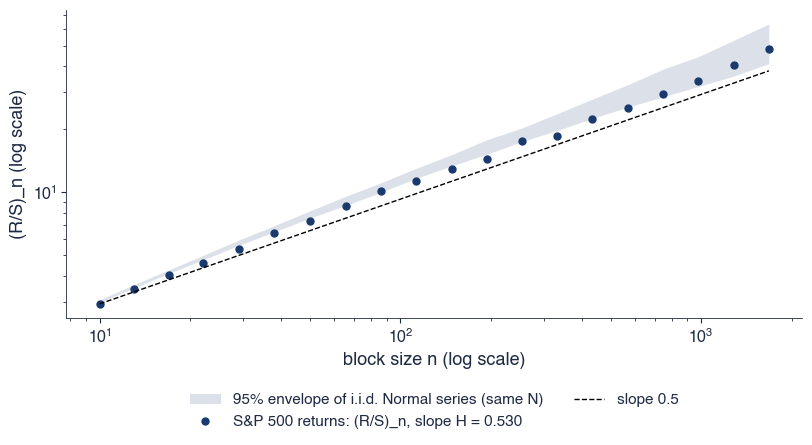

In [12]:
# Solution
def b1_memory(k='sp500', save=True, reps=SEM_REPS):
    """R/S, DFA, GPH and Lo's test of the daily returns, with the 95% band of i.i.d. Normal series of the same
    length; chart: the R/S plot of the returns inside the Monte Carlo envelope."""
    r = returns(k)
    x = r.values
    N = len(x)
    est = all_estimates(x)
    mc = mc_null(N, reps)
    sizes = block_sizes(N)
    rng = np.random.default_rng(SEED + 41)
    env = np.array([rs_curve(rng.standard_normal(N), sizes)[1] for _ in range(min(reps, 200))])
    lo, hi = np.quantile(env, 0.025, axis=0), np.quantile(env, 0.975, axis=0)
    n, rs = rs_curve(x, sizes)
    # the chart is always drawn; it is saved only if save=True
    fig, ax = plt.subplots(figsize=(9.5, 4.0))
    ax.fill_between(n, lo, hi, color=st.MainBlue, alpha=0.15, lw=0, label='95% envelope of i.i.d. Normal series (same N)')
    ax.loglog(n, rs, 'o', color=COLORS[k], ms=5, label=f"{NAME[k]} returns: (R/S)_n, slope H = {est['rs']:.3f}")
    ax.loglog(n, n ** 0.5 * rs[0] / n[0] ** 0.5, color='black', ls='--', lw=1.0, label='slope 0.5')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('block size n (log scale)')
    ax.set_ylabel('(R/S)_n (log scale)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('ch11_sem_b1')
    verdict = {m: bool(est[m] > mc[m2]['q975'] or est[m] < mc[m2]['q025']) for m, m2 in [('rs', 'rs'), ('dfa', 'dfa'), ('gph_H', 'gph')]}
    return {'k': k, 'n': N, 'first': r.index[0].date().isoformat(), 'est': est, 'mc': mc, 'outside': verdict}


b1 = b1_memory('sp500', save=False)
print(pd.DataFrame({'estimate': {k: b1['est'][k] for k in ['rs', 'dfa', 'gph_H']}, '2.5%': {k: b1['mc'][m]['q025'] for k, m in [('rs', 'rs'), ('dfa', 'dfa'), ('gph_H', 'gph')]}, '97.5%': {k: b1['mc'][m]['q975'] for k, m in [('rs', 'rs'), ('dfa', 'dfa'), ('gph_H', 'gph')]}}).round(3))
{k: b1['est'][k] for k in ['gph_d', 'gph_se', 'lo_V', 'lo_q', 'lo_V0']}

**Interpretation of the result.** No: i.i.d. series of this length give an R/S slope above 0.5 on average; every estimate lies inside its band and Lo's test does not reject short memory.

## B2 [Proposed]: BET and Banca Transilvania

**Question.** Does the BET or Banca Transilvania show long memory in returns? Model: B1.

1. Estimate $H$ with R/S, DFA and GPH for each series.
2. Compute Lo's $V(q)$ and say whether short memory is rejected at 5%.
3. Compute the Monte Carlo band of each estimator for each length.
4. Interpretation: what could explain the result for the BET?

**Report:** one table and two sentences.

In [ ]:
# Your code here


## B3 [Solved]: long memory in S&P 500 volatility

**Question.** Do the absolute and the squared S&P 500 returns have long memory, and is it in the order of the days?

1. Estimate $d$ with GPH for $m = [T^{0.5}]$ and $m = [T^{0.6}]$, and $H$ with DFA, for $|r_t|$ and $r_t^2$.
2. Report the ACF of $|r_t|$ at lags 1, 50 and 250 and the 95% band $\pm 1.96/\sqrt{T}$.
3. Shuffle $|r_t|$ at random and repeat the estimates.
4. Draw the ACF of $|r_t|$ before and after the shuffle.
5. Interpretation: does long memory in $|r_t|$ contradict the weak form of the EMH?

**Report:** a table, the chart and two sentences.

,gph05,gph06,se05,se06,m05,m06,dfa,acf1,acf50,acf250
abs,0.470,0.467,0.071,0.046,81.0,197.0,0.953,0.289,0.127,0.009
sq,0.326,0.377,0.071,0.046,81.0,197.0,0.892,0.313,0.053,-0.010
abs_shuffled,0.028,-0.001,0.071,0.046,81.0,197.0,0.498,-0.008,-0.011,0.009


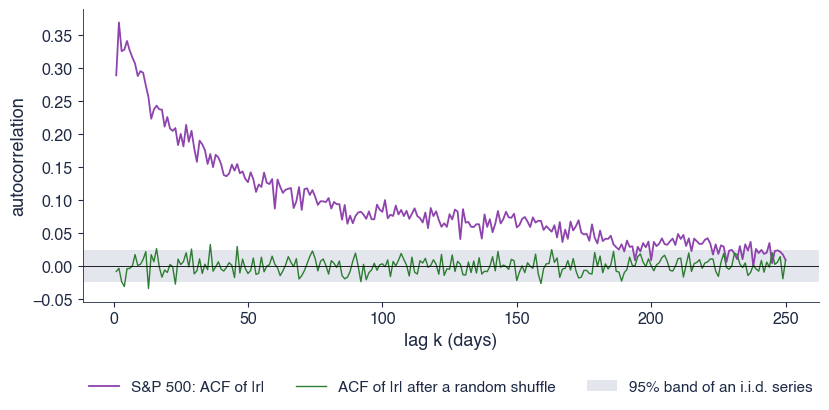

In [14]:
# Solution
def b3_volatility(k='sp500', save=True):
    """Long memory of |r| and r^2: GPH with m = T^0.5 and T^0.6, DFA, ACF at lags 1, 50, 250; the same after a random
    shuffle of |r| (the order is destroyed, the distribution kept)."""
    r = returns(k)
    a, s = np.abs(r.values), r.values ** 2
    rng = np.random.default_rng(SEED + 43)
    ash = rng.permutation(a)
    out = {'k': k, 'n': int(len(a))}
    for nm, y in [('abs', a), ('sq', s), ('abs_shuffled', ash)]:
        ac = acf(y, 250)
        out[nm] = {'gph05': gph(y, 0.5)['d'], 'gph06': gph(y, 0.6)['d'], 'se05': gph(y, 0.5)['se'], 'se06': gph(y, 0.6)['se'],
                   'm05': gph(y, 0.5)['m'], 'm06': gph(y, 0.6)['m'], 'dfa': hurst_dfa(y), 'acf1': float(ac[0]),
                   'acf50': float(ac[49]), 'acf250': float(ac[249])}
    out['band'] = float(1.96 / np.sqrt(len(a)))
    # the chart is always drawn; it is saved only if save=True
    fig, ax = plt.subplots(figsize=(9.5, 3.8))
    lags = np.arange(1, 251)
    ax.plot(lags, acf(a, 250), color=st.Purple, lw=1.3, label=f'{NAME[k]}: ACF of |r|')
    ax.plot(lags, acf(ash, 250), color=st.Forest, lw=1.0, label='ACF of |r| after a random shuffle')
    ax.axhspan(-out['band'], out['band'], color=st.MainBlue, alpha=0.12, lw=0, label='95% band of an i.i.d. series')
    ax.axhline(0, color='black', lw=0.6)
    ax.set_xlabel('lag k (days)')
    ax.set_ylabel('autocorrelation')
    st.legend_outside_bottom(ax, ncol=3, y=-0.22)
    st.check_no_grey(fig)
    if save:
        st.save_fig('ch11_sem_b3')
    return out


b3 = b3_volatility('sp500', save=False)
pd.DataFrame({k: b3[k] for k in ['abs', 'sq', 'abs_shuffled']}).T.round(3)

**Interpretation of the result.** No: the weak form concerns the direction of returns (B1); long memory in $|r_t|$ means predictable risk, which needs a volatility model (Chapter 9).

## B4 [Proposed]: Bitcoin returns and volatility

**Question.** Does Bitcoin show long memory in returns, in volatility, or in both? Models: B1, B3.

1. Estimate R/S, DFA, GPH and Lo's $V(q)$ for the returns, with the Monte Carlo bands.
2. Estimate GPH ($T^{0.5}$, $T^{0.6}$) and DFA for $|r_t|$ and $r_t^2$.
3. Repeat the volatility estimates after a random shuffle of $|r_t|$.
4. Interpretation: is Bitcoin closer to the S&P 500 or to the BET?

**Report:** one table and two sentences.

In [ ]:
# Your code here


## B5 [Solved]: rolling Hurst exponents of the S&P 500

**Question.** Has the memory of S&P 500 returns changed since 2000?

1. Estimate the DFA exponent on windows of 1000 days moved by 21 days, dated at the last day of each window.
2. Compute the 95% Monte Carlo band for $N = 1000$.
3. Report the minimum and the maximum with their dates, and the share of windows below and above the band.
4. Draw the rolling exponent with the band.
5. Interpretation: does a window outside the band prove that the market was inefficient at that time?

**Report:** six numbers, the chart and two sentences.

{'k': 'sp500',
 'n_windows': 273,
 'q025': 0.4170940468247133,
 'q975': 0.5770598049004043,
 'mean': 0.44347688653988726,
 'min': 0.3156233604346459,
 'date_min': '2008-12-31',
 'max': 0.5486814845027259,
 'date_max': '2021-07-09',
 'above': 0.0,
 'below': 0.22344322344322345,
 'first_third': 0.4406933117688613,
 'last_third': 0.46598964508493346,
 'last': 0.4279255777339411,
 'first_end': '2003-12-29',
 'last_end': '2026-09-16'}

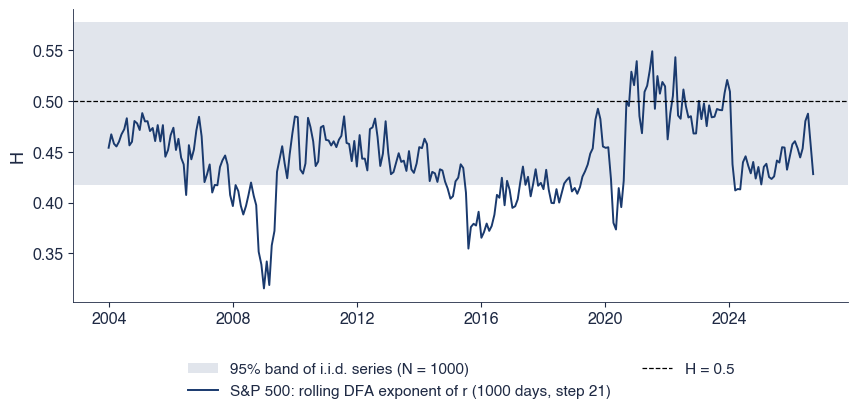

In [16]:
# Solution
def b5_rolling(k='sp500', save=True, reps=SEM_REPS):
    """Rolling DFA exponent of the returns (windows of 1000 observations moved by 21) and the 95% band of i.i.d.
    series of length 1000; share of windows above and below the band."""
    r = returns(k)
    h = rolling_hurst(r)
    band = mc_null(WINDOW, reps)['dfa']
    out = {'k': k, 'n_windows': int(len(h)), 'q025': band['q025'], 'q975': band['q975'], 'mean': float(h.mean()),
           'min': float(h.min()), 'date_min': h.idxmin().date().isoformat(), 'max': float(h.max()),
           'date_max': h.idxmax().date().isoformat(), 'above': float(np.mean(h > band['q975'])),
           'below': float(np.mean(h < band['q025'])), 'first_third': float(h.iloc[:len(h) // 3].mean()),
           'last_third': float(h.iloc[-len(h) // 3:].mean()), 'last': float(h.iloc[-1]),
           'first_end': h.index[0].date().isoformat(), 'last_end': h.index[-1].date().isoformat()}
    # the chart is always drawn; it is saved only if save=True
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.axhspan(band['q025'], band['q975'], color=st.MainBlue, alpha=0.13, lw=0, label='95% band of i.i.d. series (N = 1000)')
    ax.plot(h.index, h.values, color=COLORS[k], lw=1.4, label=f'{NAME[k]}: rolling DFA exponent of r (1000 days, step 21)')
    ax.axhline(0.5, color='black', ls='--', lw=0.9, label='H = 0.5')
    ax.set_ylabel('H')
    st.legend_outside_bottom(ax, ncol=2, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('ch11_sem_b5')
    return out


b5 = b5_rolling('sp500', save=False)
b5

**Interpretation of the result.** No: about 5% of the windows fall outside by chance and consecutive windows overlap; only long runs count. Here the runs are below the band (anti-persistence after 2008 and in 2016), never above.

## B6 [Proposed]: rolling exponents of the DAX and of Banca Transilvania

**Question.** Does the result of B5 hold for the DAX and for Banca Transilvania? Model: B5.

1. Estimate the rolling DFA exponent as in B5.
2. Report the share of windows below and above the band, and the minimum and maximum with their dates.
3. Compare the mean exponent in the first and in the last third of the windows.
4. Interpretation: which market looks more stable over time?

**Report:** one table and two sentences.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: does market memory change in crises?

**Question.** Does the Hurst exponent of returns or of volatility change in a crisis, as the fractal market hypothesis suggests? Models: B1, B3.

1. Estimate the DFA exponent of $r_t$ and of $|r_t|$ and the annualised volatility in 2017, in September 2008–August 2009 and in February 2020–February 2021, for the S&P 500 and the BET.
2. Compute the Monte Carlo band for windows of about 250 days.
3. List three reasons why one crisis year cannot settle the question.
4. Interpretation: which design would separate a change of memory from a change of volatility?

**Report:** a table and a plan for a project.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant interpreted long-memory estimates for the S&P 500 (daily, since 2000). It answered:

- (a) R/S gives $H$ above 0.5 for the returns, so returns have long memory and trends can be exploited;
- (b) $H = 0.53$ means a 53% probability that tomorrow has the same sign as today;
- (c) GPH gives $d = 0.47$ for $|r|$, so $H = d - 0.5$: absolute returns are anti-persistent;
- (d) long memory in $|r|$ contradicts the weak form of the EMH;
- (e) Lo's modified statistic lies inside $[0.809, 1.862]$, so short memory is not rejected at 5%;
- (f) for more precision, use all $T/2$ frequencies in the GPH regression.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** six verdicts with one line of justification each.

In [ ]:
# Your code here
